# Logistic Regression - Diabetes Classification

**Nama:** Hiraldy Ibrahim (2452317)  
**Nama:** Irham Malik Taufik (24523030)

## Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

## Load Dataset

In [6]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Memahami Dataset

In [7]:
print(df.info())
print(df.describe())
print(df['Outcome'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

## Preprocessing Data

In [8]:
print(df.isnull().sum())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Membangun Model Logistic Regression

In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Prediksi Data

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 1 1 1]


## Evaluasi Model

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy :', accuracy)

report = classification_report(y_test, y_pred)
print(report)

Accuracy : 0.7532467532467533
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



## Confusion Matrix

[[79 20]
 [18 37]]


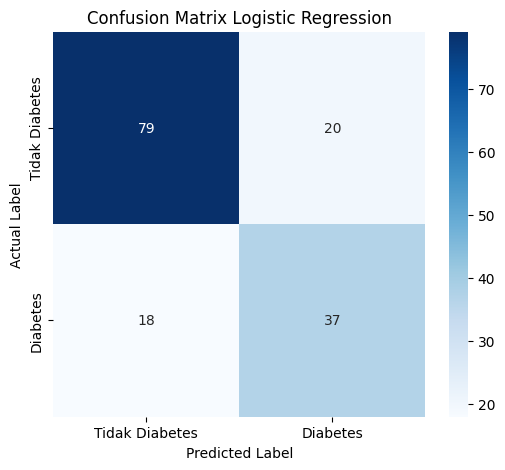

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Diabetes', 'Diabetes'],
    yticklabels=['Tidak Diabetes', 'Diabetes']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Logistic Regression')

plt.show()

## Contoh Hasil Prediksi

In [15]:
hasil = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

hasil.head(15)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,1
8,0,1
9,0,1


# Analisis Hasil

## Bagaimana Kinerja Model?
Model Logistic Regression memiliki performa yang cukup baik dalam klasifikasi diabetes. Accuracy, precision, recall, dan f1-score menunjukkan model dapat memprediksi data dengan cukup stabil.

## Makna TP, FP, TN, dan FN
- True Positive: Model memprediksi diabetes dan hasil sebenarnya diabetes.
- False Positive: Model memprediksi diabetes tetapi sebenarnya tidak diabetes.
- True Negative: Model memprediksi tidak diabetes dan hasil sebenarnya tidak diabetes.
- False Negative: Model memprediksi tidak diabetes tetapi sebenarnya diabetes.

## Kesimpulan
Logistic Regression efektif digunakan untuk klasifikasi biner seperti prediksi diabetes karena sederhana dan memiliki performa yang baik.
